In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.3 MB 3.8 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/12.3 MB 5.4 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.3 MB 5.1 MB/s eta 0:00:02
   ----------- ---------------------------- 3.7/12.3 MB 4.9 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.3 MB 5.5 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.3 MB 5.4 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.3 MB 5.5 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.3 MB 5.7 MB/s eta 0:00:01
   -----------------------------------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
cols = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]

In [37]:
train = pd.read_csv("data/adult.data", names=cols, na_values=" ?", skipinitialspace=True)
test = pd.read_csv("data/adult.test", names=cols, na_values=" ?", skipinitialspace=True, skiprows=1)

In [38]:
test["income"] = test["income"].str.replace(".", "", regex=False)

In [39]:
# Drop missing values
train = train.dropna()
test = test.dropna()

In [40]:
from sklearn.model_selection import train_test_split

# Split original training data into train and validation
X = train.drop("income", axis=1)
y = train["income"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y,  # keep class balance
)

In [41]:
train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [42]:
train['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [43]:
train['education'].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

###Preprocessing

In [44]:
train['marital-status'].value_counts()

marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

In [45]:
train['hours-per-week'].median()

np.float64(40.0)

In [46]:
train['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [47]:
train.shape

(32561, 15)

In [48]:
test.shape

(16281, 15)

In [49]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features for final test set (adult.test)
X_test = test.drop("income", axis=1)
y_test = test["income"]

# Column types based on training split
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

C:\Users\thean\AppData\Local\Temp\ipykernel_25144\256688109.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns


In [50]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

model = Pipeline([
    ("pre", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode labels for train, validation, and final test
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

# Fit model on training split
model.fit(X_train, y_train_enc)

c:\Users\thean\Desktop\adult_icome_XAI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:48:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [51]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate on validation split (from original train data)
y_val_pred = model.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val_enc, y_val_pred))
print(classification_report(y_val_enc, y_val_pred))

# Final evaluation on separate adult.test file
y_test_pred = model.predict(X_test)
print("Test accuracy (adult.test):", accuracy_score(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred))

Validation accuracy: 0.8746033370867028
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7417
           1       0.78      0.66      0.72      2352

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769

Test accuracy (adult.test): 0.8707081874577729
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12435
           1       0.77      0.65      0.70      3846

    accuracy                           0.87     16281
   macro avg       0.83      0.79      0.81     16281
weighted avg       0.87      0.87      0.87     16281



SHAP

In [52]:
#transform data for SHAP
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

#convert to dense
X_train_transformed= X_train_transformed.toarray()
X_test_transformed= X_test_transformed.toarray()
#get feature names after one-hot encoding
feature_names = model.named_steps["pre"].get_feature_names_out()
#get model
xgb_model = model.named_steps["clf"]

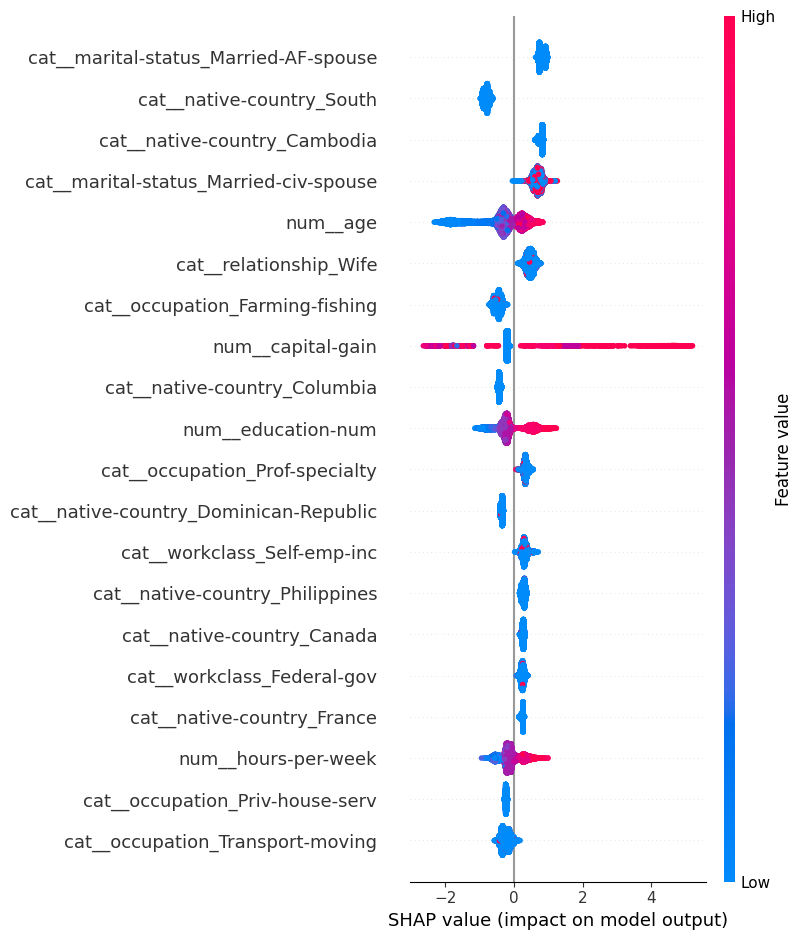

In [53]:
import shap
explainer = shap.TreeExplainer(xgb_model)
#compute shap value
shap_values = explainer.shap_values(X_train_transformed)
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


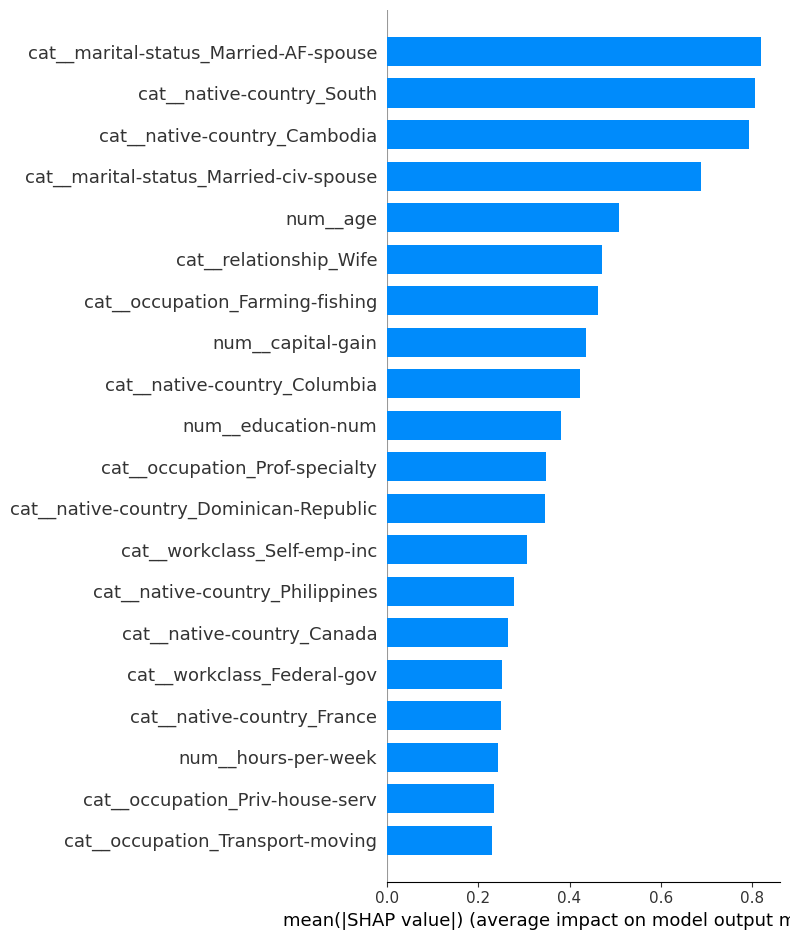

In [54]:
shap.summary_plot(shap_values, X_train_transformed, 
                  feature_names=feature_names, 
                  plot_type="bar")

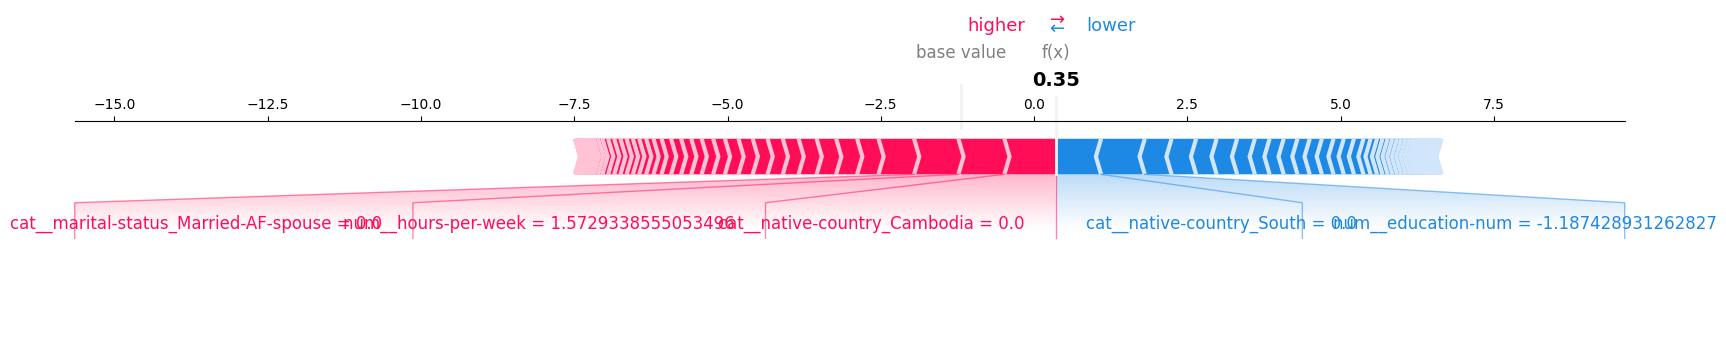

In [55]:
# Explain one instance
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train_transformed[i],
    feature_names=feature_names,
    matplotlib=True
)


In [ ]:
exp.save_to_file("lime_explanation.html")